# Independent 4,096-point Route-3 7D Simulation Bank

This notebook generates the preregistered scrambled-Sobol bank with new theta
and simulator seeds. Each 7D vector is expanded to the simulator's 8D interface
by inserting the locked `c_ctx2th`. Checkpoints are atomic and manifest-driven.
The bank is solely for synthetic cortical-rate inference.

In [1]:
from __future__ import annotations
from datetime import datetime, timezone
import importlib.metadata as mdist
import json
import os
from pathlib import Path
import platform
import sys

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
for value in (PROJECT_ROOT / "S4_sbi" / "src", PROJECT_ROOT):
    if str(value) not in sys.path:
        sys.path.insert(0, str(value))

environment = {
    "executed_utc": datetime.now(timezone.utc).isoformat(),
    "conda_environment": os.environ.get("CONDA_DEFAULT_ENV"),
    "sys.executable": sys.executable,
    "sys.prefix": sys.prefix,
    "python": platform.python_version(),
    "kernel_id": "neurolib",
    "kernel_display_name": "Python (neurolib)",
    "numpy": mdist.version("numpy"),
    "torch": mdist.version("torch"),
    "sbi": mdist.version("sbi"),
    "neurolib": mdist.version("neurolib"),
}
assert Path(sys.prefix).name.lower() == "neurolib"
display(pd.DataFrame(environment.items(), columns=["item", "value"]))

,item,value
0,executed_utc,2026-07-28T00:50:30.707056+00:00
1,conda_environment,neurolib
2,sys.executable,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
3,sys.prefix,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...
4,python,3.10.20
5,kernel_id,neurolib
6,kernel_display_name,Python (neurolib)
7,numpy,2.2.6
8,torch,2.5.1
9,sbi,0.26.1


In [2]:
from sleep_sbi.route3_7d_experiment import *

print("Preregistration SHA-256:", verify_preregistration())
gate = json.loads((PREFLIGHT_ROOT / "engineering_gate.json").read_text())
assert gate["pass"]
bank = run_training_bank_4096(max_workers=6)
display(pd.DataFrame([bank["manifest"]]))

Preregistration SHA-256: 2cedb6a68de307ab2f9233b4009a8f58854316259b6c185aeb61af5efdcbc363


,scheduled,attempted,valid,failed,failure_rate,sum_simulator_runtime_s,median_simulator_runtime_s,training_rows,validation_rows,scaling_fit_on_training_only,bank_sha256,split_sha256,schema_hash,preregistration_hash
0,4096,4096,4096,0,0.0,22935.912186,5.289772,3276,820,True,9862dc986314be3a7c940548f79cba821f1b5bdb19c055...,897f20ebd296f056a033a2fb0c64b1398a6f8852355039...,78d0da704422a03917ef4c68207f5e8e8213b0c6f6279d...,2cedb6a68de307ab2f9233b4009a8f58854316259b6c18...


## Independent reload and fixed-insertion checks

No pickle/object arrays are allowed. The first seven columns are the free
parameters; the eighth simulator column must equal the preregistered fixed value
for all 4,096 rows. Scaling is fitted on the training split only.

In [3]:
with np.load(bank["bank_path"], allow_pickle=False) as data:
    theta7 = data["theta"]; theta8 = data["theta_full_8d"]; x = data["x"]
    success = data["success"]; runtime = data["runtime_s"]
    assert theta7.shape == (4096, 7)
    assert theta8.shape == (4096, 8)
    assert x.shape == (4096, 14)
    assert np.all(theta8[:, :7] == theta7)
    assert np.all(theta8[:, 7] == fixed_c_ctx2th())
    assert np.isfinite(x[success]).all()
with np.load(bank["split_path"], allow_pickle=False) as split:
    assert np.intersect1d(split["training_indices"], split["validation_indices"]).size == 0
    print("train/validation:", len(split["training_indices"]), len(split["validation_indices"]))

train/validation: 3276 820


## Global-collision audit

Theta distance is normalized by the seven prior widths. Feature distance uses
the training-only robust scaler. The seed-noise floor is inherited from
Notebook 15, not tuned on this bank. A collision is a distant theta pair whose
14D distance falls within that noise floor.

,valid_rows,all_pairs,far_pairs,collision_count,near_collision_count,collision_fraction_of_far_pairs,noise_floor_q95_from_independent_preflight
0,4096,8386560,7878727,2192916,3759596,0.278334,2.708794


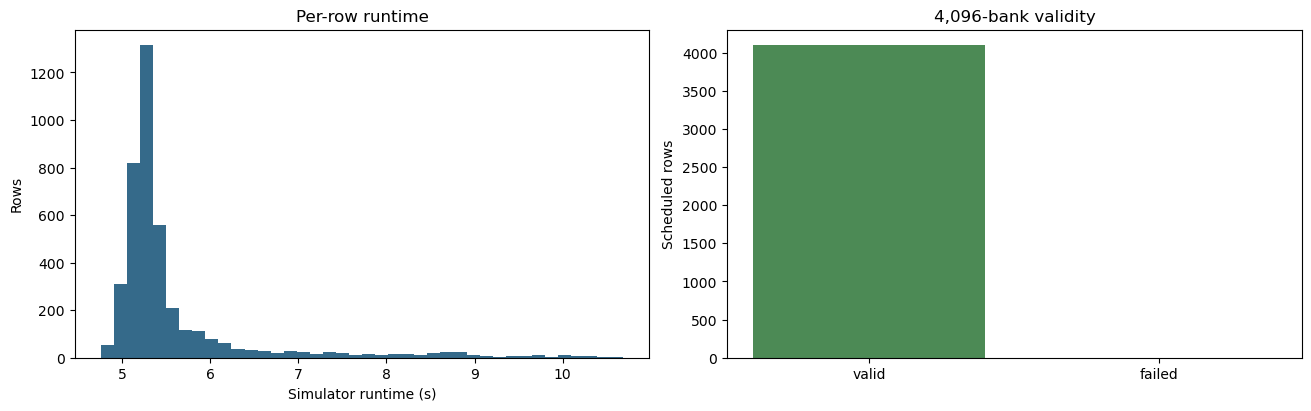

In [4]:
collision = analyze_bank_collisions(bank["bank_path"], bank["split_path"])
display(pd.DataFrame([collision]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), constrained_layout=True)
axes[0].hist(runtime, bins=40, color="#356a8a")
axes[0].set(xlabel="Simulator runtime (s)", ylabel="Rows", title="Per-row runtime")
axes[1].bar(["valid", "failed"], [success.sum(), (~success).sum()], color=["#4c8a55", "#b74d4d"])
axes[1].set(ylabel="Scheduled rows", title="4,096-bank validity")
figure_dir = BANK_ROOT / "figures"; figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "bank_runtime_and_validity.png", dpi=180)
fig.savefig(figure_dir / "bank_runtime_and_validity.svg")
plt.show()